(chapter_8)=
# Scattering Curve Models

Following {cite:p}`Pedersen_1997`, we will glance over the models.

## Form Factors
### Homogeneous sphere

$$ F_1(q,R) = \frac{3[\sin(q R) - q R \cos(q R)]}{(q R)^3} $$

In [1]:
import sys
sys.path.insert(0, r'D:\Github\molass-library')
from molass import get_version
assert get_version() >= '0.0.9', 'Please update molass to the latest version'

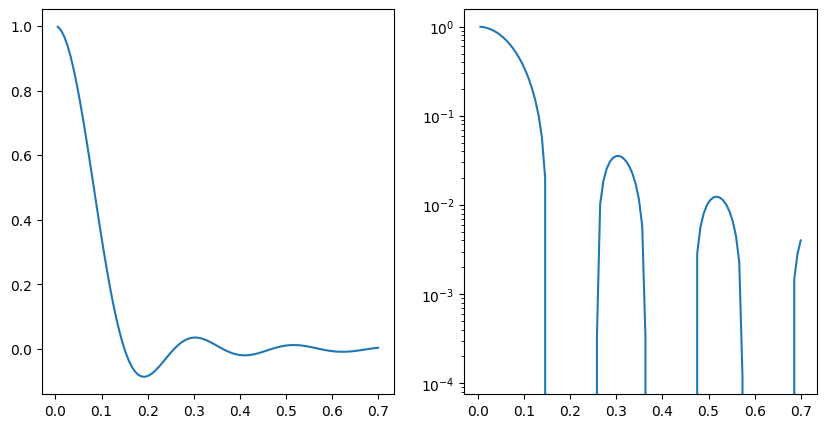

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from molass.CurveModels.Scattering.FormFactors import homogeneous_sphere

q = np.linspace(0.005, 0.7, 100)
R = 30

I = homogeneous_sphere(q, R)
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))
ax2.set_yscale('log')
for ax in ax1, ax2:
    ax.plot(q, I, label='homogeneous sphere')

Text(0.5, 0, 'q (1/Å)')

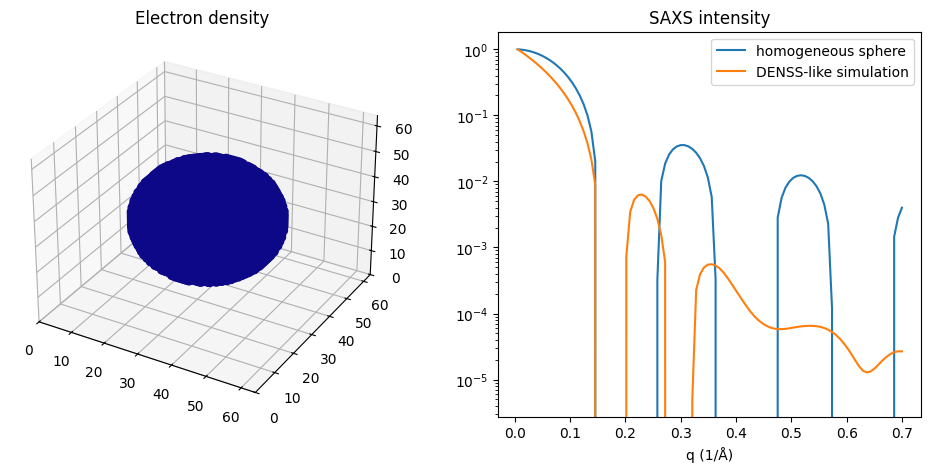

In [3]:
from molass.SAXS.Simulator import ElectronDensitySpace
from learnsaxs import draw_voxles_as_dots
N= 64
density = ElectronDensitySpace(N=N)
x, y, z = density.get_meshgrid()
c = N//2
r = 20
saxs_info = density.compute_saxs((x - c)**2 + (y - c)**2 + (z - c)**2 < r**2, q=q, use_denss=False)
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title('Electron density')
draw_voxles_as_dots(ax1, saxs_info.electron_density)

ax2 = fig.add_subplot(122)
ax2.set_title('SAXS intensity')
ax2.set_yscale('log')
ax2.plot(q, I, label='homogeneous sphere')
info = saxs_info.detector_info
ax2.plot(q, info.y, label='DENSS-like simulation')
ax2.legend()
ax2.set_xlabel('q (1/Å)')

In [ ]:
fig.savefig('saxs-2.png')